# Fatigue Life Prediction using Machine Learning

This notebook develops machine learning models to predict the fatigue life of welded joints in bridge structures using the processed fatigue dataset.

The objective is to evaluate the performance of different regression models and analyze the influence of structural and loading parameters on fatigue behavior.

Three models are considered:

• Linear Regression (baseline model)  
• Random Forest Regressor (nonlinear ensemble model)  
• XGBoost Regressor (advanced gradient boosting model)

Model performance is evaluated using RMSE, MAE, and R² metrics.

## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import joblib

## Load Processed Dataset

In [3]:
data_path = "/content/drive/MyDrive/Fatigue-Life-ML/data/processed/fatigue_dataset_clean.csv"

df = pd.read_csv(data_path)

df.head()

,base_yield_strength,base_ultimate_strength,welding_joint,welding_method,welding_voltage,welding_current,welding_speed,fatigue_specimen_type,fatigue_specimen_thickness,residual_stress,stress_concentration,load_ratio,stress_range,fatigue_life,stress_amplitude,mean_stress,normalized_stress,stress_strength_ratio,log_fatigue_life
0,355.0,575.0,Butt Joint,GMAW (MAG - Metal Active Gas Welding),27.5,290.0,10.00,Standard,8.0,210.0,1.78,0.1,185.0,2000000.0,92.5,101.75,0.521127,0.321739,6.301030
1,355.0,575.0,Butt Joint,GMAW (MAG - Metal Active Gas Welding),27.5,290.0,10.00,Standard,8.0,210.0,1.78,0.1,220.0,2000000.0,110.0,121.00,0.619718,0.382609,6.301030
2,890.0,1025.0,Cone-Cylinder Welded Joint,Manual Arc Welding,112.0,23.0,2.08,Typical CCPS Welded Joint Specimen,22.0,200.0,1.78,0.1,89.0,36400.0,44.5,48.95,0.100000,0.086829,4.561101
3,890.0,1025.0,Cone-Cylinder Welded Joint,Manual Arc Welding,112.0,23.0,2.08,Typical CCPS Welded Joint Specimen,22.0,200.0,1.78,0.1,89.0,31363.0,44.5,48.95,0.100000,0.086829,4.496418
4,890.0,1025.0,Cone-Cylinder Welded Joint,Manual Arc Welding,112.0,23.0,2.08,Typical CCPS Welded Joint Specimen,22.0,200.0,1.78,0.1,89.0,23461.0,44.5,48.95,0.100000,0.086829,4.370347


In [4]:
df.shape

(45124, 19)

## Data Preparation

In [5]:
X = df.drop(["fatigue_life", "log_fatigue_life"], axis=1)

y = df["log_fatigue_life"]

## Encode Categorical Variables

In [6]:
X = pd.get_dummies(X, drop_first=True)

## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Check shapes

In [8]:
print(X_train.shape)
print(X_test.shape)

(36099, 2179)
(9025, 2179)


## Model Development

### Linear Regression (Baseline)

In [9]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

## Random Forest

In [12]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf_baseline = rf_model.predict(X_test)

### XGBoost

In [13]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

## Model Evaluation

In [14]:
def evaluate_model(y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return rmse, mae, r2

## Evaluate models

In [15]:
lr_metrics = evaluate_model(y_test, y_pred_lr)
rf_metrics = evaluate_model(y_test, y_pred_rf_baseline)
xgb_metrics = evaluate_model(y_test, y_pred_xgb)

## Model Comparison

In [16]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [lr_metrics[0], rf_metrics[0], xgb_metrics[0]],
    "MAE": [lr_metrics[1], rf_metrics[1], xgb_metrics[1]],
    "R2": [lr_metrics[2], rf_metrics[2], xgb_metrics[2]]
})

results

,Model,RMSE,MAE,R2
0,Linear Regression,0.723021,0.549246,0.381801
1,Random Forest,0.489116,0.338340,0.717089
2,XGBoost,0.635885,0.479214,0.521828


## Feature Importance

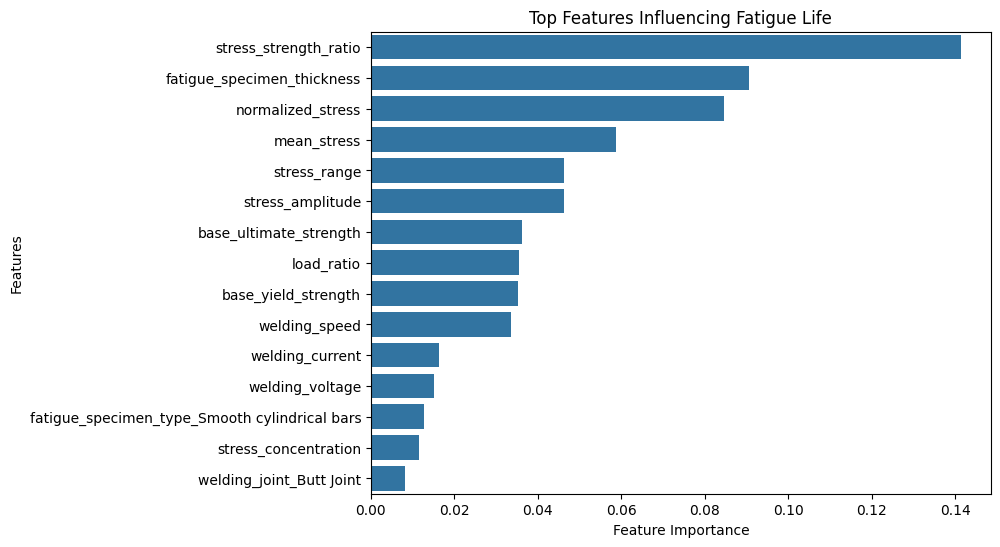

In [17]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Top Features Influencing Fatigue Life")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.savefig(
    "/content/drive/MyDrive/Fatigue-Life-ML/results/feature_importance_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Save Models

In [18]:
models_path = "/content/drive/MyDrive/Fatigue-Life-ML/models/"

joblib.dump(lr_model, models_path + "linear_regression.pkl")

joblib.dump(rf_model, models_path + "random_forest.pkl")

joblib.dump(xgb_model, models_path + "xgboost_model.pkl")

['/content/drive/MyDrive/Fatigue-Life-ML/models/xgboost_model.pkl']

## Save Model Results

In [19]:
results_path = "/content/drive/MyDrive/Fatigue-Life-ML/results/"

results.to_csv(results_path + "model_metrics.csv", index=False)

### The Random Forest and XGBoost models outperform the baseline Linear Regression model, indicating the presence of nonlinear relationships between structural parameters and fatigue life.

### Feature importance analysis highlights stress-related variables such as stress_range, stress_amplitude, and mean_stress as dominant predictors of fatigue behavior.

### These findings demonstrate the effectiveness of machine learning models in capturing complex fatigue mechanisms beyond traditional S-N curve approaches.